First 5 Rows:

   Study_Hours  Attendance  Previous_Score  Result
0    -0.978707   -1.330581        0.794451       0
1    -0.402809    0.305286        0.030437       1
2    -0.051276    1.696867        1.451954       0
3    -0.069418   -0.401971        1.452705       1
4    -0.751707    0.263197       -0.469434       0

===== Logistic Regression =====
Accuracy: 0.7444444444444445
Confusion Matrix:
 [[34 15]
 [ 8 33]]
Classification Report:
               precision    recall  f1-score   support

           0       0.81      0.69      0.75        49
           1       0.69      0.80      0.74        41

    accuracy                           0.74        90
   macro avg       0.75      0.75      0.74        90
weighted avg       0.75      0.74      0.74        90


===== KNN =====
Accuracy: 0.9111111111111111
Confusion Matrix:
 [[46  3]
 [ 5 36]]
Classification Report:
               precision    recall  f1-score   support

           0       0.90      0.94      0.92        49
           

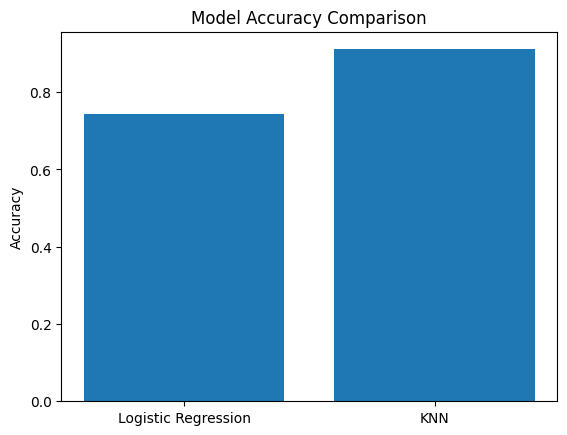

In [1]:
# ==============================
# Student Performance Prediction (ML Project)
# ==============================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# ------------------------------
# Step 1: Generate Realistic Dataset
# ------------------------------

X, y = make_classification(
    n_samples=300,
    n_features=3,
    n_informative=3,
    n_redundant=0,
    n_clusters_per_class=1,
    flip_y=0.08,  # adds some noise
    class_sep=1.0,
    random_state=42
)

df = pd.DataFrame(X, columns=['Study_Hours', 'Attendance', 'Previous_Score'])
df['Result'] = y

print("First 5 Rows:\n")
print(df.head())

# ------------------------------
# Step 2: Split Features & Target
# ------------------------------

X = df[['Study_Hours', 'Attendance', 'Previous_Score']]
y = df['Result']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

# ------------------------------
# Step 3: Feature Scaling
# ------------------------------

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# ------------------------------
# Step 4: Train Logistic Regression
# ------------------------------

log_model = LogisticRegression()
log_model.fit(X_train_scaled, y_train)

y_pred_log = log_model.predict(X_test_scaled)

# ------------------------------
# Step 5: Train KNN
# ------------------------------

knn_model = KNeighborsClassifier(n_neighbors=5)
knn_model.fit(X_train_scaled, y_train)

y_pred_knn = knn_model.predict(X_test_scaled)

# ------------------------------
# Step 6: Evaluation
# ------------------------------

print("\n===== Logistic Regression =====")
print("Accuracy:", accuracy_score(y_test, y_pred_log))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_log))
print("Classification Report:\n", classification_report(y_test, y_pred_log))

print("\n===== KNN =====")
print("Accuracy:", accuracy_score(y_test, y_pred_knn))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_knn))
print("Classification Report:\n", classification_report(y_test, y_pred_knn))

# ------------------------------
# Step 7: Cross Validation
# ------------------------------

cv_scores = cross_val_score(log_model, scaler.fit_transform(X), y, cv=5)

print("\nCross Validation Accuracy Scores:", cv_scores)
print("Mean CV Accuracy:", np.mean(cv_scores))

# ------------------------------
# Step 8: Accuracy Comparison Plot
# ------------------------------

accuracies = [
    accuracy_score(y_test, y_pred_log),
    accuracy_score(y_test, y_pred_knn)
]

models = ['Logistic Regression', 'KNN']

plt.figure()
plt.bar(models, accuracies)
plt.title("Model Accuracy Comparison")
plt.ylabel("Accuracy")
plt.show()